# Portfolio Optimization on the Efficient Frontier
### Mean-Variance Optimization & Monte Carlo Simulation over a 10-Year US Equity Universe

**Author:** Michael-Nikolas Fotopoulos
**Date:** June 2026

---

## Overview

This project applies **Modern Portfolio Theory (MPT)** to a real, self-collected market dataset:
**213 US equities** with complete **10-year daily price histories (2016 – 2026)**, sourced from a
personal EODHD SQLite database (~2 GB).

Rather than relying on a small hand-picked basket, the full investable universe is fed into two
complementary engines:

1. **Monte Carlo simulation** — 500,000 random long-only portfolios are sampled to map the
   feasible risk/return space and shade it by Sharpe ratio.
2. **Mean-Variance Optimization (MVO)** — the *analytical* efficient frontier is solved with
   quadratic programming, isolating the **Global Minimum-Variance** portfolio, the
   **Tangency (Maximum-Sharpe)** portfolio, and the **Capital Market Line (CML)**.

A second stage takes the optimal portfolio beyond textbook MPT into **portfolio-manager risk
analytics**, benchmarked against a **buy-and-hold S&P 500 (^GSPC)**: equity curve, drawdowns,
Sortino/Calmar/Treynor, Beta/Alpha/Information-Ratio, up-/down-capture, and Value-at-Risk.

### Methodology
1. **Data engineering** — load raw OHLC, **algorithmically detect & back-adjust stock splits**,
   build a clean common-history panel.
2. **Estimation** — annualized expected returns ($\mu$) and the covariance matrix ($\Sigma$).
3. **Simulation + Optimization** — Monte Carlo cloud + QP-solved efficient frontier.
4. **Risk diagnostics** — a full PM tear-sheet on the optimal allocation, **benchmarked against the
   S&P 500**: Sharpe/Sortino/Calmar/Treynor, Beta/Alpha/Information-Ratio, up-/down-capture,
   VaR/CVaR, drawdown duration, normalized growth vs. buy-and-hold, and rolling 1-year Sharpe.


## Mathematical Framework

For a portfolio of $n$ assets with weight vector $w \in \mathbb{R}^n$ (long-only, fully invested):

$$\sum_{i=1}^{n} w_i = 1, \qquad w_i \ge 0.$$

**Expected portfolio return** — inner product of weights and annualized mean returns:
$$E(R_p) = w^\top \mu = \sum_{i=1}^{n} w_i\, E(R_i)$$

**Portfolio volatility** — from the annualized covariance matrix $\Sigma$:
$$\sigma_p = \sqrt{w^\top \Sigma\, w}$$

**Sharpe ratio** — excess return per unit of total risk, against the risk-free rate $R_f$:
$$\text{Sharpe} = \frac{E(R_p) - R_f}{\sigma_p}$$

### The Efficient Frontier (Quadratic Program)
The frontier is the locus of minimum-variance portfolios for each attainable target return
$R^\*$ — a convex QP solved across a grid of targets:
$$\min_{w}\; w^\top \Sigma\, w \quad \text{s.t.}\quad w^\top \mu = R^\*,\;\; \mathbf{1}^\top w = 1,\;\; w \ge 0$$

### The Tangency Portfolio & Capital Market Line
The **Tangency portfolio** maximizes the Sharpe ratio over the long-only simplex:
$$w^\* = \arg\max_{w}\; \frac{w^\top \mu - R_f}{\sqrt{w^\top \Sigma\, w}}$$
Combining the risk-free asset with $w^\*$ traces the **Capital Market Line**, the line of optimal
risk-adjusted portfolios:
$$E(R) = R_f + \frac{E(R_{w^\*}) - R_f}{\sigma_{w^\*}}\,\sigma.$$


In [1]:
# --- Imports & configuration ---
import os, sqlite3, json, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.optimize import minimize

TRADING_DAYS = 252
YEARS        = 10
SEED         = 42
np.random.seed(SEED)

# Local EODHD database (falls back to the bundled CSV if the DB is unavailable).
DB_PATH   = r"C:\Users\Michael\Desktop\data\eodhd_market_data.db"
CSV_PATH  = os.path.join("data", "universe_adj_close.csv.gz")
SP500_CSV = os.path.join("data", "sp500.csv.gz")

sns.set_theme(style="whitegrid", context="notebook")

## 1. Data Engineering: Split-Adjusted Daily Prices

The raw `prices` table stores **unadjusted** closes, so every stock split appears as a huge
artificial one-day crash (e.g. NVIDIA's 2024 10-for-1 split looks like a −90% return). Left
uncorrected these would devastate the covariance matrix.

The helper below **detects splits algorithmically**: any one-day price ratio whose reciprocal
snaps to an integer factor $k \ge 2$ (within tolerance) is treated as a split, while moves inside
the normal "earnings" range are left untouched — so a genuine −40% earnings crash is never
mistaken for a corporate action. Prices are then **back-adjusted** into a continuous series.


In [2]:
# --- Split detection + back-adjustment ---
def back_adjust(close, tol=0.03, move=0.45):
    """Back-adjust a raw close series for stock splits (forward & reverse)."""
    s = close.astype(float)
    r = s / s.shift(1)
    factors = pd.Series(1.0, index=s.index)
    for dt, ratio in r.items():
        if not np.isfinite(ratio) or abs(ratio - 1) < move:
            continue
        if ratio < 1:                                  # forward split: today = prev / k
            k = round(1.0 / ratio)
            if k >= 2 and abs(1.0/ratio - k) / k <= tol:
                factors[dt] = 1.0 / k
        else:                                          # reverse split: today = prev * k
            k = round(ratio)
            if k >= 2 and abs(ratio - k) / k <= tol:
                factors[dt] = float(k)
    cumf = factors[::-1].cumprod()[::-1].shift(-1).fillna(1.0)   # product of splits AFTER t
    return s * cumf


def load_prices():
    """Adjusted-close panel for all full-history names over the 10y window."""
    if os.path.exists(DB_PATH):
        con = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
        end = pd.Timestamp(pd.read_sql_query(
            "SELECT MAX(datetime) m FROM prices WHERE timeframe='EOD'", con)["m"][0])
        start = end - pd.DateOffset(years=YEARS)
        syms = [r[0] for r in con.execute(
            "SELECT DISTINCT symbol FROM prices WHERE timeframe='EOD'")]
        adj = {}
        for sym in syms:
            raw = pd.read_sql_query(
                "SELECT datetime, close FROM prices WHERE symbol=? AND timeframe='EOD' "
                "ORDER BY datetime", con, params=(sym,), parse_dates=["datetime"]
            ).set_index("datetime")["close"]
            adj[sym] = back_adjust(raw).loc[start:end]
        con.close()
        px = pd.DataFrame(adj).sort_index()
        cal = px.index
        keep = [c for c in px.columns
                if px[c].first_valid_index() is not None
                and px[c].first_valid_index() <= start + pd.Timedelta(days=7)
                and px[c].notna().sum() >= 0.98 * len(cal)]
        px = px[keep].dropna()
        px.to_csv(CSV_PATH, compression="gzip")           # refresh bundled copy
    else:
        print("DB not found - loading bundled adjusted-price panel.")
        px = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)
    return px


prices = load_prices()
print(f"Universe : {prices.shape[1]} stocks x {prices.shape[0]} trading days")
print(f"Window   : {prices.index.min().date()}  ->  {prices.index.max().date()}")
prices.iloc[-3:, :6]

Universe : 213 stocks x 2514 trading days
Window   : 2016-05-31  ->  2026-05-29


,NVDA.US,MSFT.US,AAPL.US,GOOG.US,AMZN.US,META.US
datetime,,,,,,
2026-05-27,212.60,412.67,310.85,384.83,271.85,635.26
2026-05-28,214.25,426.99,312.51,386.12,274.00,635.29
2026-05-29,211.14,450.24,312.06,376.43,270.64,632.51


## 2. Returns, Annualized Moments & the Risk-Free Rate

Daily simple returns are computed and lightly winsorized at $\pm50\%$ as a guard against any
residual bad ticks. The mean vector and covariance matrix are annualized by $\times 252$. The
risk-free rate is pulled live from the 10-Year Treasury yield (`^TNX`), with a documented
fallback if the feed is unavailable.

In [3]:
# --- Returns + annualized moments ---
returns = prices.pct_change().dropna().clip(-0.50, 0.50)
mu  = returns.mean().values * TRADING_DAYS          # annualized expected returns
cov = returns.cov().values  * TRADING_DAYS          # annualized covariance matrix
tickers = [c.replace(".US", "") for c in prices.columns]
n_assets = len(mu)

def get_rf(default=0.0438):
    try:
        import yfinance as yf
        h = yf.Ticker("^TNX").history(period="5d")
        if not h.empty:
            return float(h["Close"].iloc[-1]) / 100.0, "^TNX live"
    except Exception:
        pass
    return default, "fallback (feed unavailable)"

rf, rf_src = get_rf()
print(f"Assets         : {n_assets}")
print(f"Risk-free rate : {rf:.2%}  ({rf_src})")

Failed to get ticker '^TNX' reason: Expecting value: line 1 column 1 (char 0)


$^TNX: possibly delisted; No price data found  (period=5d)


Assets         : 213
Risk-free rate : 4.38%  (fallback (feed unavailable))


## 3. Monte Carlo Simulation (500,000 Portfolios)

With 213 assets, *uniform* random weights would collapse to a tiny blob near the equal-weight
centroid (law of large numbers). To map the feasible space properly, each portfolio instead
holds a **random sparse subset** of names with Dirichlet weights — spanning everything from
single-stock bets to broadly diversified mixes. The cloud is shaded by Sharpe ratio.

In [4]:
# --- Vectorized, batched Monte Carlo ---
def monte_carlo(mu, cov, rf, n=500_000, batch=50_000, max_k=30):
    nA = len(mu)
    R, V, S = [], [], []
    best = (-1e9, None); done = 0
    while done < n:
        m = min(batch, n - done)
        W = np.zeros((m, nA))
        ks = np.random.randint(1, min(max_k, nA) + 1, size=m)
        for i in range(m):
            idx = np.random.choice(nA, ks[i], replace=False)
            W[i, idx] = np.random.dirichlet(np.ones(ks[i]))
        pr = W @ mu
        pv = np.sqrt(np.einsum("ij,jk,ik->i", W, cov, W))
        ps = (pr - rf) / pv
        R.append(pr); V.append(pv); S.append(ps)
        j = ps.argmax()
        if ps[j] > best[0]: best = (ps[j], W[j].copy())
        done += m
    return np.concatenate(R), np.concatenate(V), np.concatenate(S), best[1]

mc_ret, mc_vol, mc_shp, mc_best = monte_carlo(mu, cov, rf)
print(f"{len(mc_ret):,} portfolios simulated | best Monte-Carlo Sharpe = {mc_shp.max():.3f}")

500,000 portfolios simulated | best Monte-Carlo Sharpe = 1.383


## 4. Analytical Optimization (Quadratic Programming)

The exact frontier is solved with `scipy`'s SLSQP, supplying **analytic gradients**
($\nabla\, w^\top\Sigma w = 2\Sigma w$) so the 213-asset problem solves in seconds. We extract the
Global Minimum-Variance portfolio, the Tangency (Max-Sharpe) portfolio, and the frontier curve.

In [5]:
# --- Long-only mean-variance optimization (analytic gradients) ---
def variance(w, cov):     return w @ cov @ w
def variance_jac(w, cov): return 2 * cov @ w
def vol(w, cov):          return np.sqrt(w @ cov @ w)

BNDS = tuple((0, 1) for _ in range(n_assets))
SUM1 = {"type": "eq", "fun": lambda w: w.sum() - 1, "jac": lambda w: np.ones_like(w)}

def min_variance(cov):
    res = minimize(variance, np.full(n_assets, 1/n_assets), args=(cov,), jac=variance_jac,
                   method="SLSQP", bounds=BNDS, constraints=[SUM1],
                   options={"maxiter": 500, "ftol": 1e-12})
    return res.x

def max_sharpe(mu, cov, rf, restarts=4):
    def neg(w):
        g, v = w @ mu - rf, vol(w, cov); return -g / v
    def neg_jac(w):
        g, v = w @ mu - rf, vol(w, cov); return -(mu / v - g * (cov @ w) / v**3)
    best = None
    for s in range(restarts):
        x0 = np.full(n_assets, 1/n_assets) if s == 0 else np.random.dirichlet(np.ones(n_assets))
        res = minimize(neg, x0, jac=neg_jac, method="SLSQP", bounds=BNDS,
                       constraints=[SUM1], options={"maxiter": 1000, "ftol": 1e-12})
        if res.success and (best is None or res.fun < best.fun): best = res
    return best.x

def efficient_frontier(mu, cov, n_pts=50):
    w_mv = min_variance(cov); r_mv = w_mv @ mu
    targets = np.linspace(r_mv, mu.max(), n_pts)
    vols, rets, w0 = [], [], np.full(n_assets, 1/n_assets)
    for t in targets:
        cons = [SUM1, {"type": "eq", "fun": lambda w, t=t: w @ mu - t,
                       "jac": lambda w, t=t: mu}]
        res = minimize(variance, w0, args=(cov,), jac=variance_jac, method="SLSQP",
                       bounds=BNDS, constraints=cons, options={"maxiter": 800, "ftol": 1e-12})
        if res.success:
            vols.append(vol(res.x, cov)); rets.append(t); w0 = res.x
    return np.array(vols), np.array(rets)

w_mv = min_variance(cov)
w_ms = max_sharpe(mu, cov, rf)
fv, fr = efficient_frontier(mu, cov)

def perf(w):
    r, v = w @ mu, vol(w, cov); return r, v, (r - rf) / v
r_mv, v_mv, s_mv = perf(w_mv)
r_ms, v_ms, s_ms = perf(w_ms)
print(f"Min-Variance : return {r_mv:6.2%} | vol {v_mv:6.2%} | Sharpe {s_mv:.3f}")
print(f"Tangency     : return {r_ms:6.2%} | vol {v_ms:6.2%} | Sharpe {s_ms:.3f}")

Min-Variance : return 10.77% | vol 12.66% | Sharpe 0.505
Tangency     : return 37.48% | vol 21.07% | Sharpe 1.571


### Optimal Allocation — Tangency Portfolio

In [6]:
alloc = (pd.Series(w_ms, index=tickers)
           .sort_values(ascending=False)
           .loc[lambda s: s > 0.005]
           .rename("Weight"))
alloc.to_frame().style.format("{:.2%}").set_caption("Tangency weights (> 0.5%)")

,Weight
LLY,22.33%
PWR,12.54%
NVDA,11.99%
WMT,9.52%
PGR,9.11%
MU,6.07%
AXON,5.45%
AMD,5.42%
NEM,4.71%
LNG,4.57%


## 5. Visualizing the Efficient Frontier

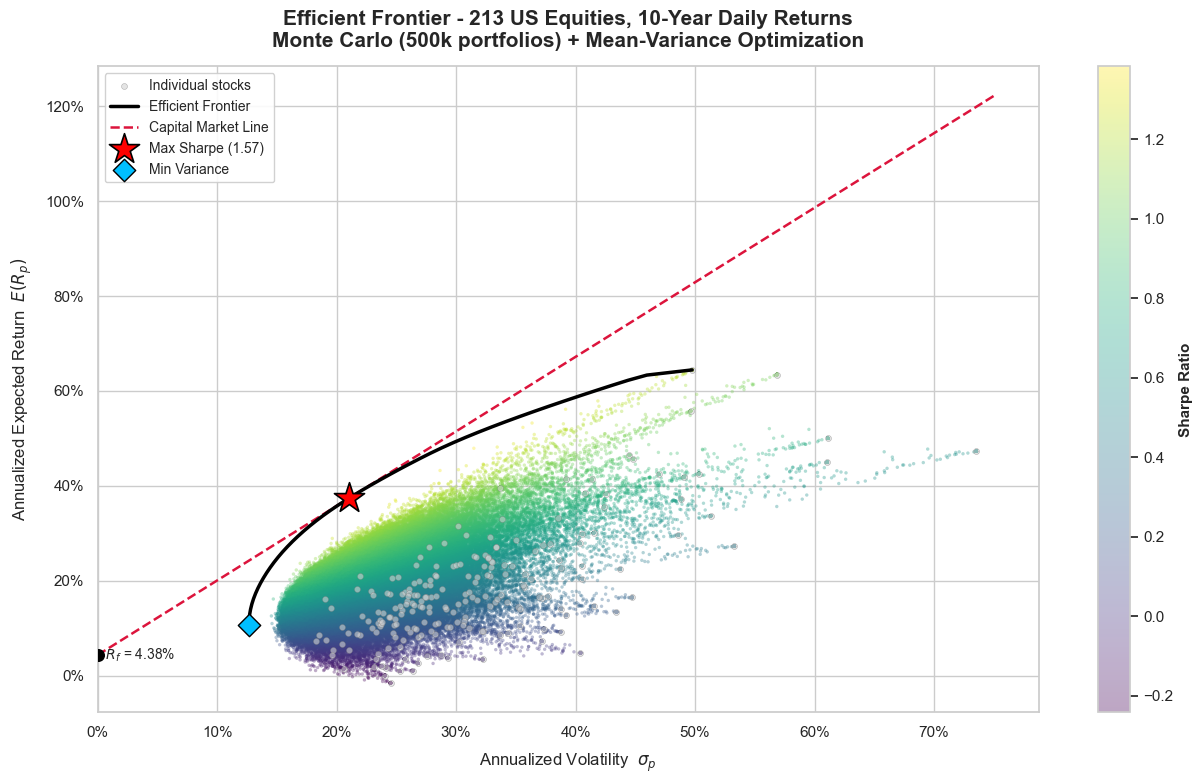

In [7]:
fig, ax = plt.subplots(figsize=(13, 8))
sc = ax.scatter(mc_vol, mc_ret, c=mc_shp, cmap="viridis", s=6, alpha=0.35,
                edgecolors="none", rasterized=True)
cbar = fig.colorbar(sc, ax=ax); cbar.set_label("Sharpe Ratio", fontsize=11, weight="bold")

ax.scatter(np.sqrt(np.diag(cov)), mu, c="lightgray", s=18, alpha=0.6,
           edgecolors="gray", linewidths=0.4, label="Individual stocks", zorder=2)
ax.plot(fv, fr, color="black", lw=2.5, label="Efficient Frontier", zorder=4)
x_cml = np.linspace(0, mc_vol.max() * 1.02, 50)
ax.plot(x_cml, rf + s_ms * x_cml, "--", color="crimson", lw=1.8,
        label="Capital Market Line", zorder=3)
ax.scatter(v_ms, r_ms, marker="*", s=520, c="red", edgecolors="black", linewidths=1.2,
           zorder=6, label=f"Max Sharpe ({s_ms:.2f})")
ax.scatter(v_mv, r_mv, marker="D", s=130, c="deepskyblue", edgecolors="black",
           linewidths=1.0, zorder=6, label="Min Variance")
ax.scatter(0, rf, marker="o", s=70, c="black", zorder=6)
ax.annotate(f"  $R_f$ = {rf:.2%}", (0, rf), fontsize=10, va="center")

ax.set_xlim(left=0)
ax.set_title("Efficient Frontier - 213 US Equities, 10-Year Daily Returns\n"
             "Monte Carlo (500k portfolios) + Mean-Variance Optimization",
             fontsize=15, weight="bold", pad=14)
ax.set_xlabel("Annualized Volatility  $\\sigma_p$", fontsize=12, labelpad=8)
ax.set_ylabel("Annualized Expected Return  $E(R_p)$", fontsize=12, labelpad=8)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9, fontsize=10)
fig.tight_layout()
fig.savefig("efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading the chart.** The Monte-Carlo cloud fills the attainable risk/return region; the
black curve is the analytically optimal boundary. The **Max-Sharpe (Tangency)** portfolio is the
single point where a ray from the risk-free rate is tangent to the frontier — the steepest
risk-adjusted line achievable, i.e. the **Capital Market Line**. No random portfolio (and no
single stock) beats it on a risk-adjusted basis, which is exactly why the optimizer's Sharpe
exceeds the best of 500,000 random draws.

## 6. Portfolio Risk & Performance Tear-Sheet (vs. S&P 500)

Mean-variance optimization only sees $\mu$ and $\Sigma$ — it says nothing about *path*
(drawdowns), *tail* (extreme losses), or *benchmark-relative* behaviour. This section produces a
full **portfolio-manager tear-sheet** for each allocation, with the **S&P 500 (^GSPC)** as both a
column and the **market benchmark** for Beta / Alpha / Information-Ratio / Capture.

The S&P 500 series is bundled in `data/sp500.csv.gz` (price index, matching our split-adjusted
price-return methodology) and reloaded live if a feed is reachable. Metrics span six families:

- **Return:** CAGR, annualized return
- **Risk-adjusted:** Sharpe, Sortino, Calmar, Treynor, Information Ratio
- **Drawdown:** max drawdown & its duration
- **Tail:** VaR / CVaR (95%), skew, excess kurtosis
- **Benchmark-relative (vs S&P 500):** Beta, Alpha, tracking error, up/down capture
- **Consistency:** hit rate, best / worst day

> These are **in-sample** realized statistics (weights estimated on the same window), so absolute
> levels are an upper bound — but the *relative* comparison, and the comparison to a passive
> buy-and-hold S&P 500, is informative.

In [8]:
# --- Load the S&P 500 benchmark (bundled; live-refresh if reachable) ---
def load_sp500(index):
    sp = None
    try:                                               # optional live refresh (Yahoo chart API)
        p1 = int((index.min() - pd.Timedelta(days=10)).timestamp())
        p2 = int((index.max() + pd.Timedelta(days=3)).timestamp())
        url = (f"https://query2.finance.yahoo.com/v8/finance/chart/%5EGSPC"
               f"?period1={p1}&period2={p2}&interval=1d")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        j = json.loads(urllib.request.urlopen(req, timeout=15).read().decode())
        res = j["chart"]["result"][0]
        sp = pd.Series(res["indicators"]["quote"][0]["close"],
                       index=pd.to_datetime(res["timestamp"], unit="s").normalize()).dropna()
        sp = sp[~sp.index.duplicated()].sort_index()
        pd.DataFrame({"SP500": sp.reindex(index, method="ffill")}).to_csv(SP500_CSV, compression="gzip")
    except Exception:
        pass
    if sp is None:
        sp = pd.read_csv(SP500_CSV, index_col=0, parse_dates=True)["SP500"]
    return sp.reindex(index, method="ffill")

sp_px  = load_sp500(prices.index)
sp_ret = sp_px.pct_change().reindex(returns.index)
mkt    = sp_ret                                          # market benchmark = S&P 500
rf_d   = rf / TRADING_DAYS
print(f"S&P 500 loaded: {sp_px.first_valid_index().date()} -> {sp_px.last_valid_index().date()} "
      f"| total return x{(sp_px.iloc[-1]/sp_px.iloc[0]):.2f}")

S&P 500 loaded: 2016-05-31 -> 2026-05-29 | total return x3.61


In [9]:
# --- Diagnostics + full tear-sheet (benchmark = S&P 500) ---
w_eq   = np.full(n_assets, 1/n_assets)
series = {
    "Max-Sharpe (Tangency)": pd.Series(returns.values @ w_ms, index=returns.index),
    "Min-Variance":          pd.Series(returns.values @ w_mv, index=returns.index),
    "Equal-Weight":          pd.Series(returns.values @ w_eq, index=returns.index),
    "S&P 500":               sp_ret,
}
colors = {"Max-Sharpe (Tangency)": "crimson", "Min-Variance": "deepskyblue",
          "Equal-Weight": "darkorange", "S&P 500": "black"}

def diagnostics(d):
    eq = (1 + d).cumprod(); dd = eq / eq.cummax() - 1
    longest = cur = 0
    for u in (eq < eq.cummax()):
        cur = cur + 1 if u else 0; longest = max(longest, cur)
    ann   = d.mean() * TRADING_DAYS
    cagr  = eq.iloc[-1] ** (TRADING_DAYS / len(d)) - 1
    volan = d.std() * np.sqrt(TRADING_DAYS)
    var95 = np.percentile(d, 5)
    beta  = np.cov(d, mkt)[0, 1] / np.var(mkt)
    act   = d - mkt; te = act.std() * np.sqrt(TRADING_DAYS)
    return dict(
        eq=eq, dd=dd, daily=d,
        CAGR=cagr, Ann_Return=ann, Volatility=volan,
        Sharpe=(ann - rf) / volan, Sortino=(ann - rf) / (d[d < 0].std() * np.sqrt(TRADING_DAYS)),
        Calmar=cagr / abs(dd.min()), MaxDD=dd.min(), MaxDD_Days=longest,
        VaR95=var95, CVaR95=d[d <= var95].mean(),
        Beta=beta, Alpha=((d.mean() - rf_d) - beta * (mkt.mean() - rf_d)) * TRADING_DAYS,
        Treynor=(ann - rf) / beta, InfoRatio=(act.mean() * TRADING_DAYS) / te if te > 1e-9 else np.nan,
        TrackErr=te, UpCapture=d[mkt > 0].mean() / mkt[mkt > 0].mean(),
        DownCapture=d[mkt < 0].mean() / mkt[mkt < 0].mean(),
        Skew=d.skew(), Kurtosis=d.kurt(), HitRate=(d > 0).mean(),
        BestDay=d.max(), WorstDay=d.min())

D = {k: diagnostics(v) for k, v in series.items()}

rows = [("CAGR","pct"),("Ann_Return","pct"),("Volatility","pct"),
        ("Sharpe","r"),("Sortino","r"),("Calmar","r"),("Treynor","r"),("InfoRatio","r"),
        ("MaxDD","pct"),("MaxDD_Days","d"),
        ("VaR95","pct"),("CVaR95","pct"),("Skew","r"),("Kurtosis","r"),
        ("Beta","r"),("Alpha","pct"),("TrackErr","pct"),("UpCapture","r"),("DownCapture","r"),
        ("HitRate","pct"),("BestDay","pct"),("WorstDay","pct")]
labels = {"Ann_Return":"Annual Return","MaxDD":"Max Drawdown","MaxDD_Days":"Max DD Duration (days)",
          "VaR95":"VaR 95%","CVaR95":"CVaR 95% (ES)","Beta":"Beta (vs S&P 500)","Alpha":"Alpha (annual)",
          "InfoRatio":"Information Ratio","TrackErr":"Tracking Error","UpCapture":"Up Capture",
          "DownCapture":"Down Capture","Kurtosis":"Excess Kurtosis","HitRate":"Hit Rate (% up days)",
          "BestDay":"Best Day","WorstDay":"Worst Day"}
def _fmt(v, t):
    if v is None or (isinstance(v, float) and np.isnan(v)): return "—"
    return f"{v:.2%}" if t == "pct" else (f"{int(v)}" if t == "d" else f"{v:.2f}")
tearsheet = pd.DataFrame({k: [_fmt(D[k][m], t) for m, t in rows] for k in series},
                         index=[labels.get(m, m.replace("_", " ")) for m, _ in rows])
tearsheet

,Max-Sharpe (Tangency),Min-Variance,Equal-Weight,S&P 500
CAGR,42.24%,10.48%,17.71%,13.75%
Annual Return,37.48%,10.77%,17.96%,14.53%
Volatility,21.07%,12.66%,18.14%,18.06%
Sharpe,1.57,0.50,0.75,0.56
Sortino,2.10,0.63,0.89,0.67
Calmar,1.70,0.44,0.49,0.41
Treynor,0.33,0.12,0.14,0.10
Information Ratio,2.20,-0.33,0.79,—
Max Drawdown,-24.81%,-23.79%,-36.46%,-33.92%
Max DD Duration (days),169,485,372,512


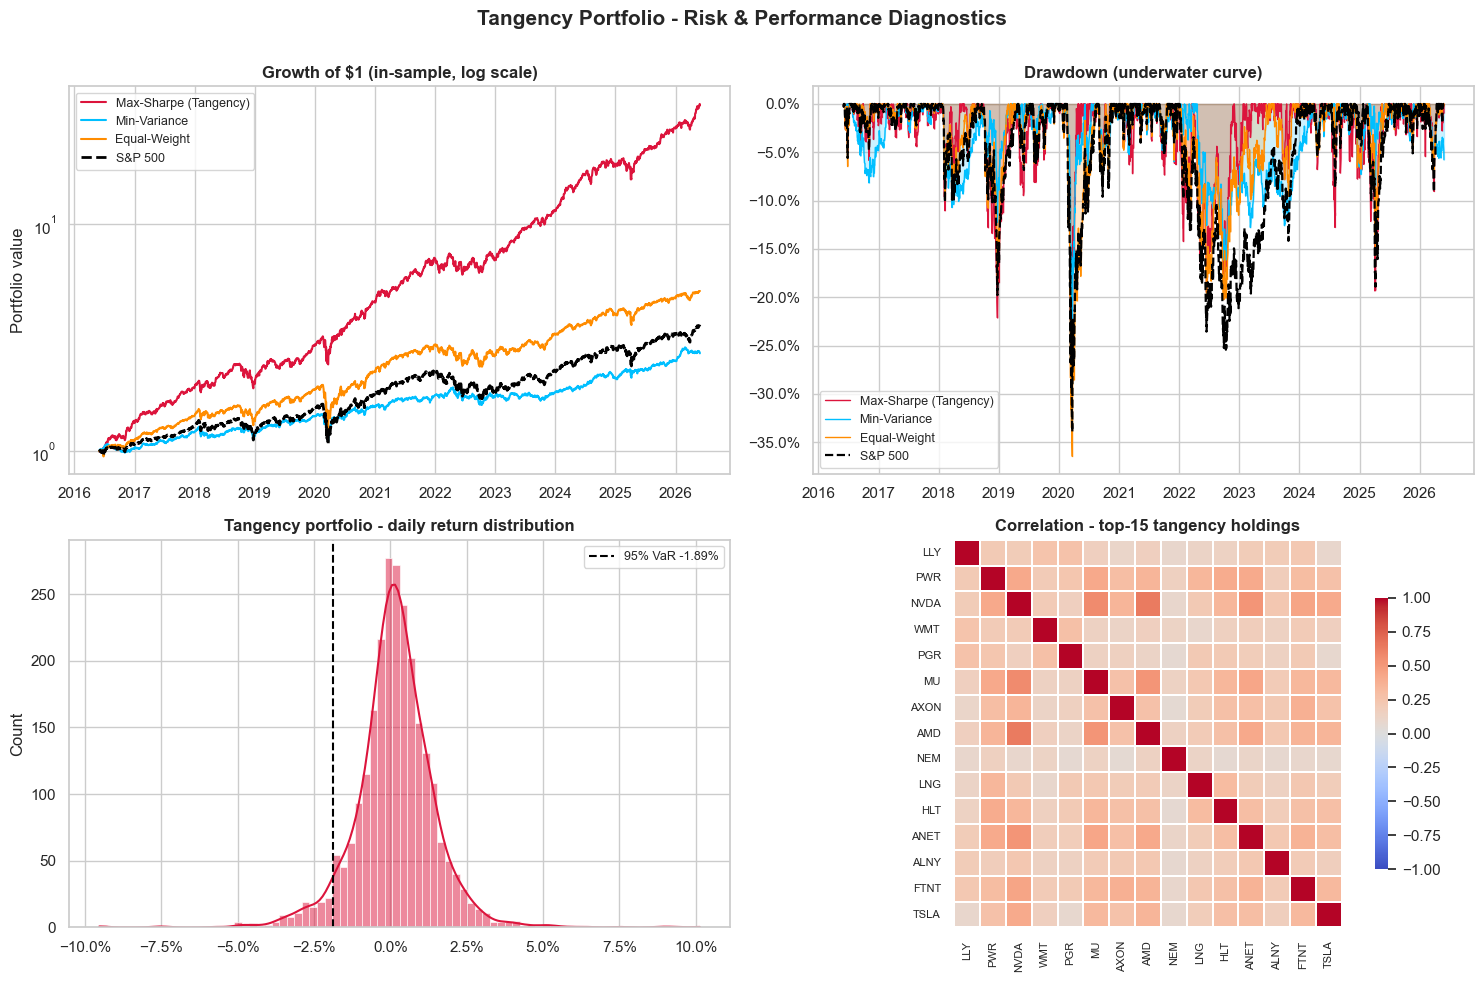

In [10]:
fig2, axs = plt.subplots(2, 2, figsize=(15, 10))

for k, d in D.items():                                   # (a) equity curve
    axs[0,0].plot(d["eq"].index, d["eq"], label=k, color=colors[k],
                  lw=2.0 if k == "S&P 500" else 1.5, ls="--" if k == "S&P 500" else "-")
axs[0,0].set_yscale("log"); axs[0,0].set_title("Growth of $1 (in-sample, log scale)", weight="bold")
axs[0,0].set_ylabel("Portfolio value"); axs[0,0].legend(fontsize=9)

for k, d in D.items():                                   # (b) drawdown
    axs[0,1].plot(d["dd"].index, d["dd"], color=colors[k],
                  lw=1.6 if k == "S&P 500" else 1.0, ls="--" if k == "S&P 500" else "-", label=k)
    if k != "S&P 500":
        axs[0,1].fill_between(d["dd"].index, d["dd"], 0, color=colors[k], alpha=0.20)
axs[0,1].set_title("Drawdown (underwater curve)", weight="bold")
axs[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)); axs[0,1].legend(fontsize=9)

tang = D["Max-Sharpe (Tangency)"]                        # (c) return distribution
sns.histplot(tang["daily"], bins=80, kde=True, ax=axs[1,0], color="crimson", alpha=0.5)
axs[1,0].axvline(tang["VaR95"], color="black", ls="--", label=f"95% VaR {tang['VaR95']:.2%}")
axs[1,0].set_title("Tangency portfolio - daily return distribution", weight="bold")
axs[1,0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)); axs[1,0].legend(fontsize=9)

topn = pd.Series(w_ms, index=tickers).sort_values(ascending=False).head(15).index.tolist()
corr = returns[[t + ".US" for t in topn]].corr(); corr.index = topn; corr.columns = topn
sns.heatmap(corr, ax=axs[1,1], cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7}, linewidths=0.3)
axs[1,1].set_title("Correlation - top-15 tangency holdings", weight="bold")
axs[1,1].tick_params(labelsize=8)

fig2.suptitle("Tangency Portfolio - Risk & Performance Diagnostics", fontsize=15, weight="bold")
fig2.tight_layout(rect=[0, 0, 1, 0.98])
fig2.savefig("risk_performance.png", dpi=200, bbox_inches="tight")
plt.show()

### Normalized Growth vs. Buy-and-Hold S&P 500

The headline comparison for any active strategy: would you have beaten simply buying and holding
the index? The top panel normalizes every strategy to **\$1 at inception**; the bottom panel shows
**relative strength** — each portfolio's cumulative value *divided by* the S&P 500's, so a line
above 1.0 means it is beating buy-and-hold at that point in time.

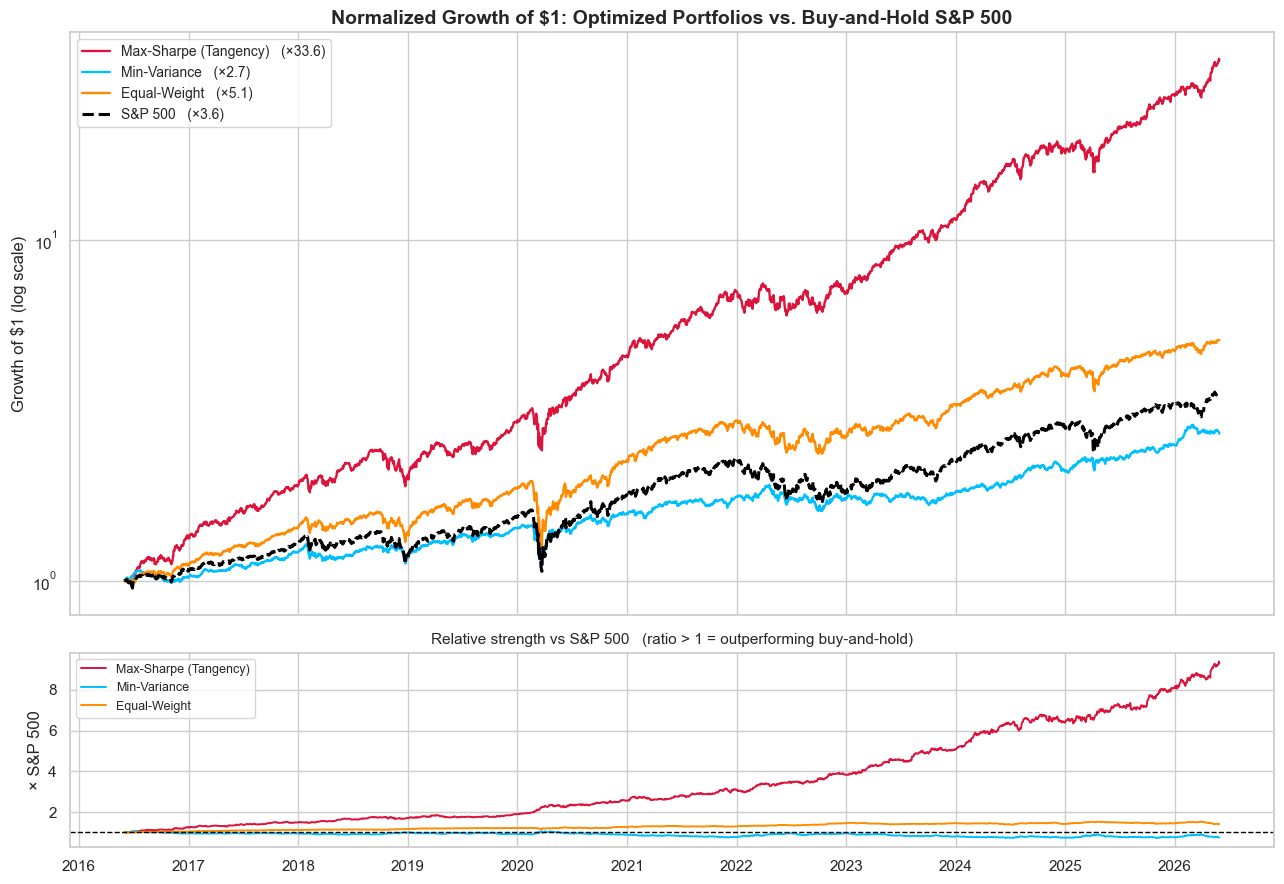

In [11]:
fig4, (axA, axB) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})
for k, d in D.items():
    axA.plot(d["eq"].index, d["eq"], color=colors[k],
             lw=2.2 if k == "S&P 500" else 1.7, ls="--" if k == "S&P 500" else "-",
             label=f"{k}   (×{d['eq'].iloc[-1]:.1f})")
axA.set_yscale("log")
axA.set_title("Normalized Growth of $1: Optimized Portfolios vs. Buy-and-Hold S&P 500",
              fontsize=14, weight="bold")
axA.set_ylabel("Growth of $1 (log scale)"); axA.legend(fontsize=10, loc="upper left")

sp_eq = D["S&P 500"]["eq"]
for k in ["Max-Sharpe (Tangency)", "Min-Variance", "Equal-Weight"]:
    axB.plot(D[k]["eq"].index, D[k]["eq"] / sp_eq, color=colors[k], lw=1.4, label=k)
axB.axhline(1.0, color="black", ls="--", lw=1)
axB.set_title("Relative strength vs S&P 500   (ratio > 1 = outperforming buy-and-hold)", fontsize=11)
axB.set_ylabel("× S&P 500"); axB.legend(fontsize=9, loc="upper left")
fig4.tight_layout()
fig4.savefig("growth_vs_sp500.png", dpi=200, bbox_inches="tight")
plt.show()

### Rolling 1-Year Sharpe Ratio

A single full-sample Sharpe hides *when* risk-adjusted performance was earned. The 252-day rolling
Sharpe shows how each strategy — and the S&P 500 — held up through the 2018 selloff, the 2020
COVID crash, and the 2022 bear market.

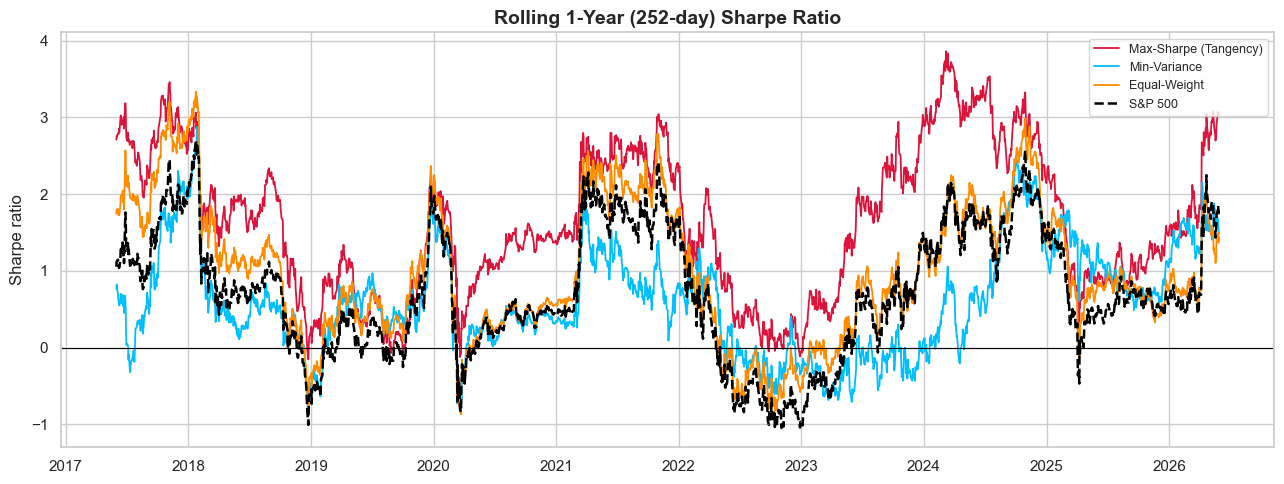

In [12]:
fig3, ax3 = plt.subplots(figsize=(13, 5))
for k, d in D.items():
    s = d["daily"]
    rs = (s.rolling(TRADING_DAYS).mean() * TRADING_DAYS - rf) / (s.rolling(TRADING_DAYS).std() * np.sqrt(TRADING_DAYS))
    ax3.plot(rs.index, rs, color=colors[k], lw=1.8 if k == "S&P 500" else 1.3,
             ls="--" if k == "S&P 500" else "-", label=k)
ax3.axhline(0, color="black", lw=0.8)
ax3.set_title("Rolling 1-Year (252-day) Sharpe Ratio", fontsize=14, weight="bold")
ax3.set_ylabel("Sharpe ratio"); ax3.legend(fontsize=9, loc="upper right")
fig3.tight_layout()
fig3.savefig("rolling_sharpe.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Interpretation & Takeaways

**The optimizer dominates naive allocation *and* the index.** Over 2016–2026 the **Tangency**
portfolio delivered a far higher Sharpe and Calmar than both the Equal-Weight basket and a passive
**buy-and-hold S&P 500**, while suffering a *shallower* maximum drawdown — the core promise of
mean-variance optimization made concrete. The **Min-Variance** portfolio, as designed, posts the
lowest volatility of the group.

**It generates real alpha, not just beta.** Benchmarked against the **S&P 500**, the tangency
portfolio runs a near-market beta yet earns a large positive **annual alpha** and a strong
**information ratio**, with **up-capture > 1 and down-capture < 1** — it participates more in
rallies than in selloffs. The **rolling 1-year Sharpe** stays mostly positive but clearly
compresses during 2018, the 2020 COVID crash, and 2022, a reminder that risk-adjusted edge is
regime-dependent.

**Mind the tails.** All series show **negative skew and high excess kurtosis** — daily equity
returns are fat-tailed, so VaR/CVaR matter and Gaussian risk models would understate extreme
losses.

**Diversification is real, not assumed.** The top-holdings correlation heatmap shows the optimizer
pairing high-return names (LLY, NVDA, AXON) with low-correlation stabilizers (WMT, PGR, NEM), so
idiosyncratic risk partially cancels — the covariance matrix doing its job.

**Honest caveats** (the part that matters most for a research piece):
- **In-sample.** $\mu$ and $\Sigma$ are estimated on the same window used to score performance;
  out-of-sample Sharpes are always lower. A walk-forward / shrinkage extension is the natural
  next step. The S&P 500 comparison is *not* in-sample-fit, so the outperformance there is the
  more honest yardstick — though it still benefits from survivorship.
- **Survivorship bias.** The universe is *today's* 213 survivors with full 10-year histories;
  delisted/merged names are absent, inflating returns. Absolute figures are an upper bound.
- **Estimation error.** Max-Sharpe weights are notoriously sensitive to noise in $\mu$; in
  production one would add weight caps, Ledoit-Wolf covariance shrinkage, or resampled frontiers.
- **Price-return basis.** Both the portfolios and the S&P 500 are compared on a price (split-only)
  basis, excluding dividends, for a like-for-like comparison.

**Bottom line.** From a raw 2 GB market database, this notebook builds a clean split-adjusted
universe, maps the full risk/return space by simulation, solves the efficient frontier exactly,
and validates the optimal portfolio with PM-grade risk analytics benchmarked against the S&P 500 —
an end-to-end Modern Portfolio Theory pipeline on real data.
